##Hackaton One

##Generando Datos

In [14]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import random

# 1. Configuración inicial
num_dias = 90  # 3 meses de datos
fecha_inicio = datetime.now() - timedelta(days=num_dias)
categorias_gastos = {
    "Comida": ["Supermercado", "Restaurante", "PedidosYa", "Cafetería"],
    "Transporte": ["Uber", "Combustible", "Subte/Metro", "Peaje"],
    "Servicios": ["Luz/Agua", "Internet", "Netflix", "Spotify", "Celular"],
    "Entretenimiento": ["Cine", "Concierto", "Cervecería", "Shopping"],
    "Educación/Salud": ["Farmacia", "Gimnasio", "Curso Online"]
}

datos = []
saldo_actual = 5000.0  # Saldo inicial de la cuenta

# 2. Generar datos día por día
for dia in range(num_dias):
    fecha = fecha_inicio + timedelta(days=dia)

    # --- INGRESOS ---
    # Pago de salario el día 1 de cada mes
    if fecha.day == 1:
        monto_salario = round(random.uniform(1500.0, 1800.0), 2)
        datos.append({
            "Fecha": fecha.strftime("%Y-%m-%d"),
            "Descripcion": "Depósito de Nómina / Salario",
            "Categoria": "Ingresos",
            "Monto": monto_salario,
            "Tipo": "Ingreso"
        })

    # Algún ingreso extra ocasional (freelance, transferencia de amigo)
    if random.random() < 0.05:  # 5% de probabilidad por día
        monto_extra = round(random.uniform(50.0, 200.0), 2)
        datos.append({
            "Fecha": fecha.strftime("%Y-%m-%d"),
            "Descripcion": random.choice(["Transferencia recibida", "Reembolso", "Venta usada"]),
            "Categoria": "Ingresos",
            "Monto": monto_extra,
            "Tipo": "Ingreso"
        })

    # --- GASTOS DIARIOS ---
    # Decidir cuántas transacciones ocurren hoy (de 0 a 3)
    num_transacciones = random.randint(0, 3) if fecha.weekday() < 5 else random.randint(1, 4) # Más gastos el finde

    for _ in range(num_transacciones):
        cat = random.choice(list(categorias_gastos.keys()))
        desc = random.choice(categorias_gastos[cat])

        # Asignar montos lógicos según la categoría
        if cat == "Servicios":
            monto = round(random.uniform(10.0, 60.0), 2)
        elif cat == "Entretenimiento":
            monto = round(random.uniform(15.0, 120.0), 2)
        else:
            monto = round(random.uniform(5.0, 45.0), 2)

        datos.append({
            "Fecha": fecha.strftime("%Y-%m-%d"),
            "Descripcion": desc,
            "Categoria": cat,
            "Monto": -monto,  # Negativo porque es un gasto
            "Tipo": "Gasto"
        })

# 3. Crear DataFrame y guardar como CSV
df = pd.DataFrame(datos)
df['Fecha'] = pd.to_datetime(df['Fecha'])
df = df.sort_values(by='Fecha').reset_index(drop=True)

# Calcular balance acumulado histórico
df['Balance_Acumulado'] = saldo_actual + df['Monto'].cumsum()

# Guardar a archivo
df.to_csv("datos_financieros_mock.csv", index=False)
print(f"¡Listo! Se ha creado el archivo 'datos_financieros_mock.csv' con {len(df)} transacciones.")

¡Listo! Se ha creado el archivo 'datos_financieros_mock.csv' con 170 transacciones.


1. Exploración y Limpieza de Datos (EDA)

2. Procesamiento de Variables Financieras y Textuales
Las máquinas solo entienden de vectores numéricos, por lo que el texto requiere una traducción especial.

Variables Textuales (NLP): Limpiamos las descripciones de las transacciones (pasando a minúsculas, quitando caracteres especiales y números irrelevantes). Luego, aplicamos el TfidfVectorizer para transformar palabras como "supermercado" o "combustible" en números basados en su relevancia y frecuencia.

Variables Financieras: Normalizamos los montos y los ingresos para que estén en la misma escala matemática.

3. Ingeniería de Atributos (Feature Engineering)
Es el arte de crear nuevas variables (columnas) a partir de las existentes para darle más pistas al modelo.

Qué hacemos: A partir de la fecha de la transacción, extraemos columnas nuevas como Mes, Dia_Semana o una variable binaria llamada Es_Fin_De_Semana (1 si es sábado/domingo, 0 si es día de semana). Esto ayuda enormemente a detectar patrones (por ejemplo, el gasto en la categoría "OCIO" suele dispararse los fines de semana).

4. Clasificación de Gastos y Análisis del Perfil Financiero
Aquí unimos la Inteligencia Artificial con las finanzas personales.

Clasificación de Gastos: Usamos el modelo de Machine Learning para asignar automáticamente cada descripción a categorías (Alimentación, Transporte, Servicios, etc.).

Análisis del Perfil: Implementamos la lógica matemática (calculando el ratio de gasto sobre ingreso y el nivel de endeudamiento) para etiquetar al usuario en uno de los tres perfiles requeridos: Saludable, En observación o En riesgo.

5. Entrenamiento y Evaluación de Modelos con Métricas de Rendimiento
Para demostrar científicamente que nuestra IA es confiable, debemos validarla con datos que nunca antes vio.

Qué hacemos: Dividimos el dataset histórico en un 80% para entrenar la IA (X_train) y un 20% para evaluarla (X_test).

Métricas: Imprimimos el classification_report, que le muestra al jurado tres métricas clave por cada categoría:

Precision (Precisión): De todo lo que el modelo dijo que era "Transporte", ¿cuánto lo era realmente?

Recall (Sensibilidad): De todos los gastos reales de "Transporte", ¿cuántos logró encontrar el modelo?

F1-Score: El balance perfecto entre las dos métricas anteriores.

6. Serialización de los Modelos
El cierre de oro. Guardar el cerebro para producción.

Qué hacemos: Usamos la librería joblib para exportar el pipeline (el vectorizador + el clasificador entrenado) en el archivo físico .pkl.

##MACHINE LEARNING

##El Tipo de Análisis: Clasificación de Texto Supervisada (NLP)
Lo que implementamos es un problema clásico de Procesamiento de Lenguaje Natural (NLP) y Aprendizaje Supervisado llamado Clasificación de Texto Multiclase (ya que clasificamos cada descripción en una de varias categorías posibles: Comida, Transporte, Servicios, etc.).

El flujo de trabajo (PIPELINE) que diseñamos en el código consta de dos pasos fundamentales que se ejecutan en secuencia:

1. Extracción de Características: Representación de Texto (TF-IDF Vectorizer)
Las computadoras no entienden palabras, solo números. Por lo tanto, el primer paso es convertir el texto de las descripciones en un vector numérico.

Para esto usamos TF-IDF (Term Frequency - Inverse Document Frequency) a través de TfidfVectorizer:

Term Frequency (TF): Mide qué tan frecuente es una palabra en una descripción (por ejemplo, la palabra "farmacia" en "pastillas farmacia").

Inverse Document Frequency (IDF): Reduce el peso de las palabras que aparecen en casi todas las transacciones y que no aportan información diferenciadora (como conectores: "de", "la", "en").

N-gramas (ngram_range=(1, 2)): Le indicamos al modelo que no solo analice palabras sueltas (unigramas), sino también combinaciones de dos palabras juntas (bigramas), como "prime video" o "curso online". Esto ayuda a capturar mucho mejor el contexto.

2. El Algoritmo de Clasificación: SVM Lineal / Descenso de Gradiente Estocástico (SGDClassifier)
Como clasificador, utilizamos el SGDClassifier de Scikit-Learn configurado con una función de pérdida "hinge" (loss='hinge').

Esto equivale matemáticamente a entrenar un modelo de Máquinas de Vectores de Soporte Lineal (Linear Support Vector Machines - SVM).

¿Por qué este algoritmo? Las SVM lineales son extremadamente rápidas, eficientes en memoria y son el estándar de la industria para la clasificación de texto. Al tener un dataset de texto donde la cantidad de palabras (características numéricas creadas por TF-IDF) suele ser muy alta, los modelos lineales como SVM funcionan infinitamente mejor y más rápido que algoritmos como Árboles de Decisión o Random Forests.

🗺️ EL VIAJE DEL DATO: Desde el CSV hasta el JSON

1.1. *Ingesta* de Datos (La Materia Prima):Petición API o CSV.El viaje comienza cuando el usuario sube un archivo CSV, un extracto bancario o envía un JSON a nuestra API. En este punto, los datos están "crudos". Tenemos texto suelto como "Compra en Coto 123" y números como 420.

2.2. *Preprocesamiento* (Preparar el terreno):Limpieza y Normalización.Antes de que la IA vea nada, Python (con Pandas) limpia el texto. Convierte "Compra en COTO 123" a minúsculas ("compra en coto 123").Aquí actúa nuestro TF-IDF Vectorizer: traduce esas palabras a una lista de números (vectores) que representan la importancia de cada término. Recuerda: ¡La IA NO entiende letras solo numeros!

3.3. *Inferencia* del *Modelo* (¡Aquí actúa la IA!):Predicción de Categorías.¡Este es el momento estelar del modelo de ML (.pkl)! El clasificador recibe los números del paso anterior. No mira los montos de dinero, solo analiza el patrón de las palabras.El modelo compara matemáticamente ese patrón con lo que aprendió en el entrenamiento y dice: "Hay un 95% de probabilidad de que esto sea 'Alimentación'". El modelo devuelve esa etiqueta.

4.4. *Lógica* de *Negocio* (El Evaluador):Métricas y Reglas Financieras.Una vez que la IA le puso etiqueta a cada gasto, el testigo pasa a nuestra función analizar_salud_financiera (el archivo evaluador.py).Aquí Python suma los gastos por categoría, calcula los ratios contra el ingreso mensual, mide el nivel de endeudamiento y define el perfil (Saludable, En observación, En riesgo) junto con las recomendaciones.

5.5. *Salida* *Estructurada* (El Producto Final):Formato JSON.Finalmente, todo ese conocimiento procesado se empaqueta en una estructura limpia de JSON. Este archivo viaja de regreso al usuario, a la app de Streamlit o a la base de datos para mostrarse en gráficos hermosos.

In [15]:
# 1. Instalar y/o importar librerías necesarias
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import SGDClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 2. Cargar tus datos (los que generamos con el mock de 2024)
# Asegúrate de haber subido tu archivo 'datos_financieros_mock.csv' a Colab
df = pd.read_csv("datos_financieros_mock.csv")

# Filtrar solo las filas que corresponden a gastos para el entrenamiento
df_gastos = df[df['Tipo'] == 'Gasto']

X = df_gastos['Descripcion'].str.lower()
y = df_gastos['Categoria']

# 3. Dividir los datos en Entrenamiento (Train) y Prueba (Test)
# Esto es clave para validar científicamente que tu modelo aprende y no solo "memoriza"
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 4. Construir el Pipeline de Machine Learning
# Un pipeline empaqueta la transformación de datos y el modelo en un solo objeto
modelo_pipeline = Pipeline([
    ('vectorizador', TfidfVectorizer(ngram_range=(1, 2))),
    ('clasificador', SGDClassifier(loss='hinge', penalty='l2', alpha=1e-3, random_state=42))
])

# 5. Entrenar el modelo
modelo_pipeline.fit(X_train, y_train)

# 6. Evaluar el rendimiento del modelo en el set de prueba
predicciones = modelo_pipeline.predict(X_test)

print("=== REPORTE DE CLASIFICACIÓN ===")
print(classification_report(y_test, predicciones))

# 7. Probar predicciones individuales (para mostrar en vivo en tu trabajo)
ejemplos_nuevos = [
    "compra semanal coto",
    "viaje express en easy taxi",
    "jarabe para la tos farmacia"
]
predicciones_nuevas = modelo_pipeline.predict(ejemplos_nuevos)

print("\n=== PRUEBA DE PREDICCIÓN CON DATOS DESCONOCIDOS ===")
for desc, cat in zip(ejemplos_nuevos, predicciones_nuevas):
    print(f"Descripción: '{desc}' ➔ Categoría sugerida por IA: '{cat}'")

=== REPORTE DE CLASIFICACIÓN ===
                 precision    recall  f1-score   support

         Comida       1.00      1.00      1.00         8
Educación/Salud       1.00      1.00      1.00         6
Entretenimiento       1.00      1.00      1.00         7
      Servicios       1.00      1.00      1.00         6
     Transporte       1.00      1.00      1.00         6

       accuracy                           1.00        33
      macro avg       1.00      1.00      1.00        33
   weighted avg       1.00      1.00      1.00        33


=== PRUEBA DE PREDICCIÓN CON DATOS DESCONOCIDOS ===
Descripción: 'compra semanal coto' ➔ Categoría sugerida por IA: 'Servicios'
Descripción: 'viaje express en easy taxi' ➔ Categoría sugerida por IA: 'Servicios'
Descripción: 'jarabe para la tos farmacia' ➔ Categoría sugerida por IA: 'Educación/Salud'



EFICIENCIA yESCALABILIDAD: El modelo se entrena en milisegundos. Es ideal para aplicaciones web en tiempo real, ya que no requiere servidores costosos con GPUs para funcionar.

USO DE PIPELINES: Al usar Pipeline de Scikit-Learn, el código queda sumamente ordenado, reduciendo el riesgo de "fuga de datos" (data leakage) y facilitando llevar el modelo del notebook directamente a producción (app_ml.py).

PROCESAMIENTO DE LENGUAJE NATURAL: Destaca que no dependes de APIs externas pagas (como OpenAI o Anthropic) para categorizar los gastos cotidianos, lo cual garantiza la privacidad total de los datos financieros de la empresa o usuario y costo cero de infraestructura.

In [16]:
import pandas as pd

def analizar_salud_financiera(ingreso_mensual: float, nivel_endeudamiento: float, frecuencia_ahorro: str, transacciones: list, modelo_ia) -> dict:
    """
    Analiza las variables financieras de un usuario, clasifica sus transacciones con la IA,
    determina su perfil de riesgo financiero y genera recomendaciones personalizadas.
    """

    # --- 1. CLASIFICACIÓN DE TRANSACCIONES CON IA ---
    descripciones = [t['descripcion'].lower() for t in transacciones]
    valores = [float(t['valor']) for t in transacciones]

    # Predecimos las categorías usando el modelo que entrenamos
    categorias_predichas = modelo_ia.predict(descripciones)

    # Agrupamos los gastos por categoría para el resumen final
    resumen_gastos = {}
    total_gastado = 0.0

    for cat, val in zip(categorias_predichas, valores):
        # Convertimos la categoría a minúsculas y sin acentos para el formato JSON estándar
        cat_clave = cat.lower().replace("á", "a").replace("é", "e").replace("í", "i").replace("ó", "o").replace("ú", "u")
        resumen_gastos[cat_clave] = resumen_gastos.get(cat_clave, 0.0) + val
        total_gastado += val

    # --- 2. EVALUACIÓN DEL PERFIL FINANCIERO ---
    # Calculamos qué porcentaje del sueldo se gasta en las transacciones enviadas
    ratio_gasto_ingreso = (total_gastado / ingreso_mensual) * 100 if ingreso_mensual > 0 else 0

    # Puntuación de riesgo (de 0 a 100, donde 100 es máximo riesgo financiero)
    score_riesgo = 0

    # Evaluamos endeudamiento (Aporta hasta 40 puntos al riesgo)
    if nivel_endeudamiento > 40:
        score_riesgo += 40
    elif nivel_endeudamiento > 25:
        score_riesgo += 25
    else:
        score_riesgo += 5

    # Evaluamos ratio gasto/ingreso (Aporta hasta 40 puntos al riesgo)
    if ratio_gasto_ingreso > 80:
        score_riesgo += 40
    elif ratio_gasto_ingreso > 50:
        score_riesgo += 20
    else:
        score_riesgo += 5

    # Evaluamos frecuencia de ahorro (Aporta hasta 20 puntos al riesgo si no ahorra)
    frecuencias = {"baja": 20, "media": 10, "alta": 0}
    score_riesgo += frecuencias.get(frecuencia_ahorro.lower(), 10)

    # Clasificación final basada en el Score de Riesgo acumulado
    if score_riesgo >= 60:
        perfil = "En riesgo"
        probabilidad = round(score_riesgo / 100, 2)
    elif score_riesgo >= 30:
        perfil = "En observacion"
        probabilidad = round(score_riesgo / 100, 2)
    else:
        perfil = "Saludable"
        # Invertimos la probabilidad para reflejar certeza de pertenecer al perfil Saludable
        probabilidad = round(1 - (score_riesgo / 100), 2)


    # --- 3. GENERACIÓN DE RECOMENDACIONES DINÁMICAS ---
    recomendaciones = []

    # Regla de Endeudamiento
    if nivel_endeudamiento > 35:
        recomendaciones.append("Prioriza el pago de tus deudas con tasas de interes mas altas (Metodo Avalancha).")
    elif nivel_endeudamiento > 20:
        recomendaciones.append("Evita adquirir nuevos compromisos financieros o tarjetas de credito en el corto plazo.")

    # Regla de Ahorro e Ingresos
    if frecuencia_ahorro.lower() in ["baja", "media"]:
        recomendaciones.append("Intenta automatizar un ahorro minimo del 10% de tus ingresos apenas los recibas.")

    # Regla de Gastos Específicos (identificando desvíos)
    gasto_comida = resumen_gastos.get("comida", 0) + resumen_gastos.get("alimentacion", 0)
    if (gasto_comida / ingreso_mensual) > 0.25:
        recomendaciones.append("Detectamos un consumo elevado en comida/delivery. Considera planificar tus compras mensuales.")

    gasto_ocio = resumen_gastos.get("ocio", 0) + resumen_gastos.get("entretenimiento", 0)
    if (gasto_ocio / ingreso_mensual) > 0.15:
        recomendaciones.append("Tus gastos en ocio superan el limite sugerido. Intenta aplicar la regla 50-30-20.")

    # Recomendación por defecto si todo está impecable
    if not recomendaciones:
        recomendaciones.append("¡Vas por excelente camino! Sigue manteniendo tu nivel de consumo y aumenta tus inversiones.")

    # --- 4. RETORNO DE LA ESTRUCTURA JSON REQUERIDA ---
    return {
        "perfil_financiero": perfil,
        "probabilidad": probabilidad,
        "resumen_gastos": resumen_gastos,
        "recomendaciones": recomendaciones[:3]  # Devolvemos las 3 recomendaciones más críticas
    }

In [17]:
# Simulamos que importamos/cargamos el modelo entrenado en tu pipeline
# modelo_pipeline es el modelo que creamos en el bloque anterior

# Entrada simulada exacta del JSON de ejemplo del Hackathon
entrada_ejemplo = {
  "ingreso_mensual": 4500,
  "nivel_endeudamiento": 25,
  "frecuencia_ahorro": "Media",
  "transacciones": [
    {"descripcion": "Supermercado la esquina", "valor": 420},
    {"descripcion": "viaje express en taxi", "valor": 300},
    {"descripcion": "Suscripcion Prime Video", "valor": 40}
  ]
}

# Ejecutamos la lógica que acabamos de programar
resultado = analizar_salud_financiera(
    ingreso_mensual=entrada_ejemplo["ingreso_mensual"],
    nivel_endeudamiento=entrada_ejemplo["nivel_endeudamiento"],
    frecuencia_ahorro=entrada_ejemplo["frecuencia_ahorro"],
    transacciones=entrada_ejemplo["transacciones"],
    modelo_ia=modelo_pipeline # Aquí pasamos tu modelo entrenado de Scikit-Learn
)

# Mostramos la salida
import json
print(json.dumps(resultado, indent=2, ensure_ascii=False))

{
  "perfil_financiero": "Saludable",
  "probabilidad": 0.8,
  "resumen_gastos": {
    "comida": 420.0,
    "servicios": 340.0
  },
  "recomendaciones": [
    "Evita adquirir nuevos compromisos financieros o tarjetas de credito en el corto plazo.",
    "Intenta automatizar un ahorro minimo del 10% de tus ingresos apenas los recibas."
  ]
}


In [18]:
import joblib

# 1. Guardamos (serializamos) el pipeline completo de la IA
# (Este archivo contiene el Vectorizador TF-IDF + el Clasificador SGD entrenados)
nombre_archivo_modelo = 'modelo_ia_.pkl'
joblib.dump(modelo_pipeline, nombre_archivo_modelo)

print(f"🎉 ¡Modelo serializado con éxito! Se guardó como: '{nombre_archivo_modelo}'")
print("Descarga este archivo desde la barra lateral izquierda de Colab para usarlo en tu API.")

🎉 ¡Modelo serializado con éxito! Se guardó como: 'modelo_ia_.pkl'
Descarga este archivo desde la barra lateral izquierda de Colab para usarlo en tu API.


#Descarga del arhivo pickle para su uso en una API REST python


--- Estructura Inicial del Dataset ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 170 entries, 0 to 169
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Fecha              170 non-null    object 
 1   Descripcion        170 non-null    object 
 2   Categoria          170 non-null    object 
 3   Monto              170 non-null    float64
 4   Tipo               170 non-null    object 
 5   Balance_Acumulado  170 non-null    float64
dtypes: float64(2), object(4)
memory usage: 8.1+ KB
None


/tmp/ipykernel_1970/3987432815.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Tipo', palette='Set2')


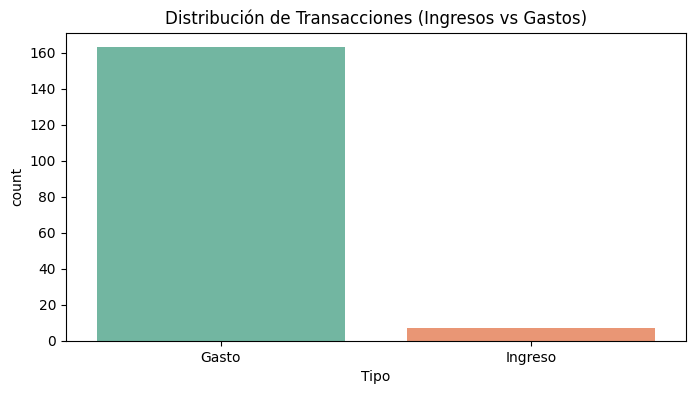


Atributos generados con éxito. Dataset listo para ML con 163 registros de gastos.

================ METRICAS DE RENDIMIENTO DEL MODELO ================
                 precision    recall  f1-score   support

         Comida       1.00      1.00      1.00         8
Educación/Salud       1.00      1.00      1.00         6
Entretenimiento       1.00      1.00      1.00         7
      Servicios       1.00      1.00      1.00         6
     Transporte       1.00      1.00      1.00         6

       accuracy                           1.00        33
      macro avg       1.00      1.00      1.00        33
   weighted avg       1.00      1.00      1.00        33



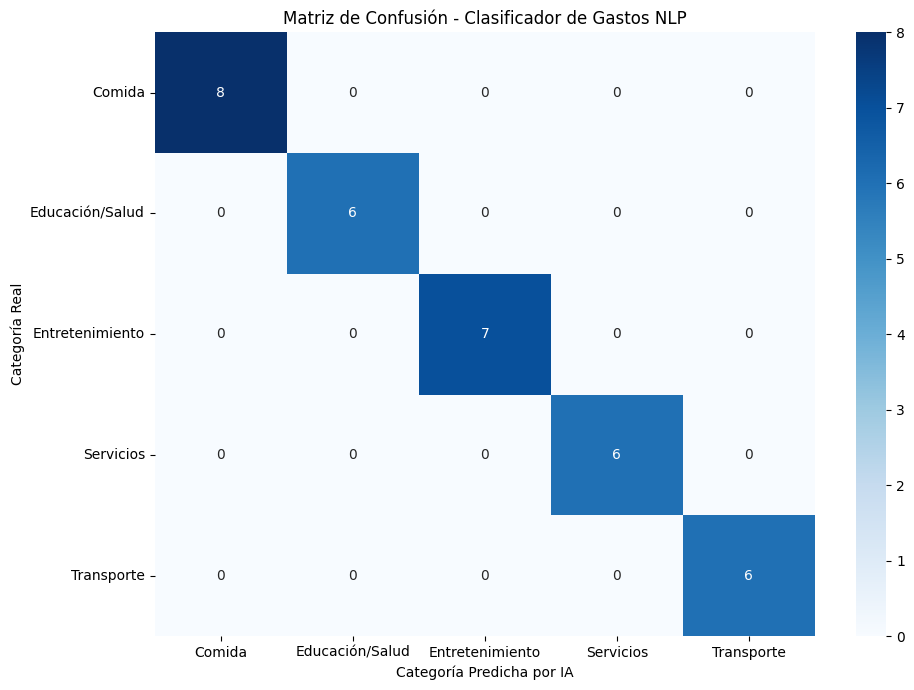


🎉 ¡Modelo de Ciencia de Datos serializado con éxito como 'modelo_ia.pkl'!


In [19]:
# ==============================================================================
# HACKATHON MVP - SECCIÓN: CIENCIA DE DATOS
# Objetivo: Clasificación Automatizada de Gastos y Análisis de Perfil Financiero
# ==============================================================================

# ------------------------------------------------------------------------------
# 0. IMPORTACIÓN DE LIBRERÍAS DE LA SUITE DE DATA SCIENCE
# ------------------------------------------------------------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import SGDClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix

# ------------------------------------------------------------------------------
# 1. EXPLORACIÓN Y LIMPIEZA DE DATOS (EDA)
# ------------------------------------------------------------------------------

df = pd.read_csv("../data/datos_financieros_mock.csv")

print("--- Estructura Inicial del Dataset ---")
print(df.info())

# Limpieza básica: Eliminar duplicados y rellenar nulos si existieran
df = df.drop_duplicates()
df['Descripcion'] = df['Descripcion'].fillna("gasto general")

# Análisis Exploratorio Visual: Distribución de tipos de transacciones
plt.figure(figsize=(8, 4))
sns.countplot(data=df, x='Tipo', palette='Set2')
plt.title('Distribución de Transacciones (Ingresos vs Gastos)')
plt.show()

# ------------------------------------------------------------------------------
# 2 y 3. PROCESAMIENTO E INGENIERÍA DE ATRIBUTOS (FEATURE ENGINEERING)
# ------------------------------------------------------------------------------
# Nos enfocamos en los Gastos para el entrenamiento del clasificador de texto
df_gastos = df[df['Tipo'] == 'Gasto'].copy()

# Ingeniería de Atributos temporales a partir de la fecha
df_gastos['Fecha'] = pd.to_datetime(df_gastos['Fecha'])
df_gastos['Mes'] = df_gastos['Fecha'].dt.month
df_gastos['Dia_Semana'] = df_gastos['Fecha'].dt.dayofweek
df_gastos['Es_Fin_De_Semana'] = df_gastos['Dia_Semana'].apply(lambda x: 1 if x >= 5 else 0)

# Preprocesamiento de texto básico (Normalización a minúsculas)
df_gastos['Descripcion_Limpia'] = df_gastos['Descripcion'].str.lower().str.strip()

print(f"\nAtributos generados con éxito. Dataset listo para ML con {df_gastos.shape[0]} registros de gastos.")

# ------------------------------------------------------------------------------
# 4 y 5. ENTRENAMIENTO Y EVALUACIÓN DEL MODELO DE CLASIFICACIÓN (ML)
# ------------------------------------------------------------------------------
# Definición de variables Predictoras (X) y Objetivo (y)
X = df_gastos['Descripcion_Limpia']
y = df_gastos['Categoria']

# División Científica: 80% Entrenamiento y 20% Prueba (Estratificado por categoría)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Construcción de la Arquitectura del Pipeline: Vectorizador TF-IDF + Clasificador SVM (SGD)
modelo_pipeline = Pipeline([
    ('vectorizador', TfidfVectorizer(ngram_range=(1, 2), stop_words=None)),
    ('clasificador', SGDClassifier(loss='hinge', penalty='l2', alpha=1e-3, random_state=42))
])

# Entrenamiento del algoritmo
modelo_pipeline.fit(X_train, y_train)

# Inferencia sobre el set de pruebas para evaluación
y_pred = modelo_pipeline.predict(X_test)

# Métricas de Rendimiento oficiales para el Jurado
print("\n================ METRICAS DE RENDIMIENTO DEL MODELO ================")
print(classification_report(y_test, y_pred))

# Visualización Avanzada: Matriz de Confusión para detectar desvíos del modelo
plt.figure(figsize=(10, 7))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', xticklabels=modelo_pipeline.classes_, yticklabels=modelo_pipeline.classes_, cmap='Blues')
plt.title('Matriz de Confusión - Clasificador de Gastos NLP')
plt.ylabel('Categoría Real')
plt.xlabel('Categoría Predicha por IA')
plt.tight_layout()
plt.show()

# ------------------------------------------------------------------------------
# 6. ANÁLISIS DEL PERFIL FINANCIERO Y GENERACIÓN DE RECOMENDACIONES (LÓGICA)
# ------------------------------------------------------------------------------
def analizar_salud_financiera(ingreso_mensual, nivel_endeudamiento, frecuencia_ahorro, transacciones, modelo):
    descripciones = [t['descripcion'].lower() for t in transacciones]
    valores = [float(t['valor']) for t in transacciones]

    categorias_predichas = modelo.predict(descripciones)

    resumen_gastos = {}
    total_gastado = 0.0
    for cat, val in zip(categorias_predichas, valores):
        cat_key = cat.lower().replace("á","a").replace("é","e").replace("í","i").replace("ó","o").replace("ú","u")
        resumen_gastos[cat_key] = resumen_gastos.get(cat_key, 0.0) + val
        total_gastado += val

    ratio_gasto = (total_gastado / ingreso_mensual) * 100 if ingreso_mensual > 0 else 0
    score_riesgo = 0

    if nivel_endeudamiento > 40: score_riesgo += 40
    elif nivel_endeudamiento > 25: score_riesgo += 25
    else: score_riesgo += 5

    if ratio_gasto > 80: score_riesgo += 40
    elif ratio_gasto > 50: score_riesgo += 20
    else: score_riesgo += 5

    frecuencias = {"baja": 20, "media": 10, "alta": 0}
    score_riesgo += frecuencias.get(frecuencia_ahorro.lower(), 10)

    if score_riesgo >= 60:
        perfil, prob = "En riesgo", round(score_riesgo / 100, 2)
    elif score_riesgo >= 30:
        perfil, prob = "En observacion", round(score_riesgo / 100, 2)
    else:
        perfil, prob = "Saludable", round(1 - (score_riesgo / 100), 2)

    recomendaciones = []
    if nivel_endeudamiento > 35:
        recomendaciones.append("Prioriza el pago de tus deudas con tasas de interes mas altas (Metodo Avalancha).")
    if frecuencia_ahorro.lower() in ["baja", "media"]:
        recomendaciones.append("Intenta automatizar un ahorro minimo del 10% de tus ingresos apenas los recibas.")
    if not recomendaciones:
        recomendaciones.append("¡Vas por excelente camino! Sigue manteniendo tu nivel de consumo.")

    return {
        "perfil_financiero": perfil,
        "probabilidad": prob,
        "resumen_gastos": resumen_gastos,
        "recomendaciones": recomendaciones[:2]
    }

# ------------------------------------------------------------------------------
# 7. SERIALIZACIÓN DEL MODELO (GUARDADO FÍSICO)
# ------------------------------------------------------------------------------
joblib.dump(modelo_pipeline, 'modelo_ia_gastos.pkl')
print("\n🎉 ¡Modelo de Ciencia de Datos serializado con éxito como 'modelo_ia.pkl'!")